In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('result - cleaned.csv')

# 2. Clean the 'dmg_ba' text column into actual numeric types
def clean_damage(val):
    if pd.isna(val): return np.nan
    val = str(val).replace('"', '').replace(',', '').strip()
    # Fix common video OCR typos (like letters substituted for numbers)
    val = val.lower().replace('t', '1')
    if val.endswith('k'):
        return float(val[:-1]) * 1000
    return float(val)

In [2]:
df['dmg_ba_numeric'] = df['dmg_ba'].apply(clean_damage)
df['dmg_ba_numeric'] = df['dmg_ba_numeric'].interpolate()
df['interval_dmg'] = df['dmg_ba_numeric'].diff().fillna(0)

df_negative_damage = df[df['interval_dmg'] < 0]
print(df_negative_damage.shape[0], "rows with negative damage")
df_negative_damage[['timestamp', 'dmg_ba', 'interval_dmg']].head(5)

2 rows with negative damage


,timestamp,dmg_ba,interval_dmg
320,437.16,0,-2.483236e+14
332,449.04,0,-1.483136e+14


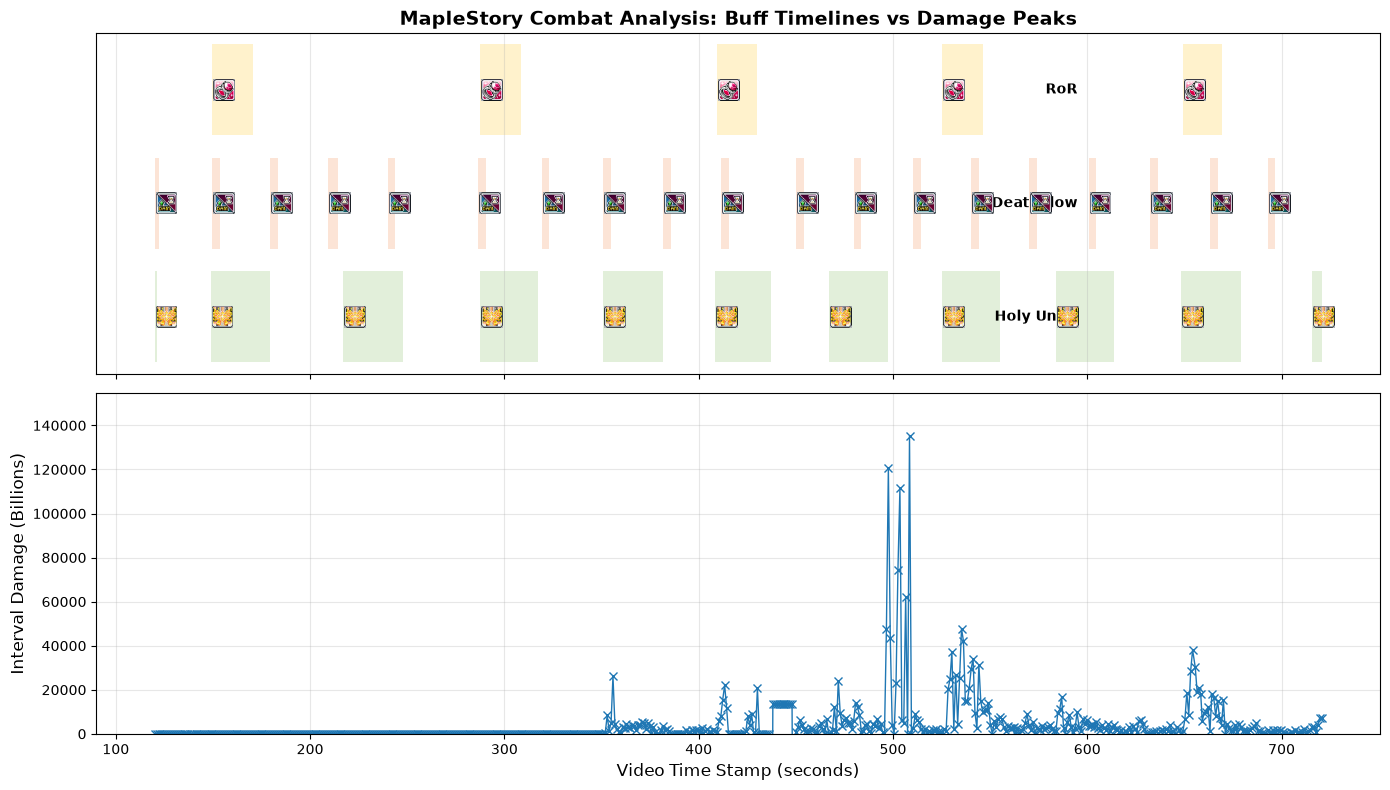

In [3]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import pandas as pd # Kept for 'pd.notna' and general robustness.

# 1. Create a 2-Panel Figure (Top for Buff Timelines, Bottom for Damage)
fig, (ax_buffs, ax_dmg) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                       gridspec_kw={'height_ratios': [1, 2]})

# --- BOTTOM PANEL: DAMAGE GRAPH ---
ax_dmg.plot(df['timestamp'], df['interval_dmg'] / 1e9, color='#1f77b4', marker='x', linewidth=1)
ax_dmg.set_ylabel('Interval Damage (Billions)', fontsize=12)
ax_dmg.set_ylim(bottom=0)
ax_dmg.set_xlabel('Video Time Stamp (seconds)', fontsize=12)
ax_dmg.grid(True, alpha=0.3)

# --- TOP PANEL: BUFF TRACKS ---
buff_tracks = {
    'ror_buff': {'y_level': 3, 'color': '#FFF2CC', 'icon': 'buff_icons/ror.png', 'label': 'RoR'},
    'deathblow_buff': {'y_level': 2, 'color': '#FCE4D6', 'icon': 'buff_icons/deathblow.png', 'label': 'Deathblow'},
    'holy_unity_buff': {'y_level': 1, 'color': '#E2EFDA', 'icon': 'buff_icons/holy_unity.png', 'label': 'Holy Unity'}
}

def add_track_icon(ax, image_path, x_pos, y_pos):
    try:
        img = plt.imread(image_path)
        imagebox = OffsetImage(img, zoom=0.35)
        ab = AnnotationBbox(imagebox, (x_pos, y_pos), frameon=False, xycoords='data', box_alignment=(0, 0.5))
        ax.add_artist(ab)
    except FileNotFoundError:
        ax.text(x_pos, y_pos, "[Icon]", fontsize=8, ha='left', va='center')

for buff_name, config in buff_tracks.items():
    y = config['y_level']
    ax_buffs.text(595, y, config['label'], ha='right', va='center', fontweight='bold', fontsize=10)
    for i in range(len(df)-1):
        if pd.notna(df.loc[i, buff_name]):
            t_start = df.loc[i, 'timestamp']
            t_end = df.loc[i+1, 'timestamp']
            ax_buffs.fill_between([t_start, t_end], y-0.4, y+0.4, color=config['color'], edgecolor='none')
            if i == 0 or pd.isna(df.loc[i-1, buff_name]):
                add_track_icon(ax_buffs, config['icon'], t_start + 0.5, y)

ax_buffs.set_ylim(0.5, len(buff_tracks) + 0.5)
ax_buffs.get_yaxis().set_visible(False)
ax_buffs.grid(True, axis='x', alpha=0.3)
ax_buffs.set_title('MapleStory Combat Analysis: Buff Timelines vs Damage Peaks', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()